# Unsupervised Topic Discovery with NMF and LDA

## Goal

This notebook applies unsupervised topic modelling to text documents.

The goal is to discover hidden themes in news-style discussion posts without using the original labels during model training.

The notebook compares two topic modelling approaches:

- Non-negative Matrix Factorization, NMF
- Latent Dirichlet Allocation, LDA

## Main question

Can unsupervised models discover meaningful document topics from raw text?

## Important note

The original dataset has labels, but this notebook does not use them during topic modelling.

The labels are only used at the end as a post-hoc sanity check to see whether discovered topics align with known categories.

In [1]:
import warnings
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
selected_categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.med",
    "sci.space",
    "talk.politics.misc",
    "soc.religion.christian"
]

newsgroups = fetch_20newsgroups(
    subset="all",
    categories=selected_categories,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=RANDOM_STATE
)

documents = newsgroups.data
true_labels = newsgroups.target
true_label_names = np.array(newsgroups.target_names)

print("Number of documents:", len(documents))
print("Selected categories:", true_label_names)

Number of documents: 5716
Selected categories: ['comp.graphics' 'rec.sport.baseball' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.misc']


In [3]:
df = pd.DataFrame({
    "text": documents,
    "true_label_id": true_labels,
    "true_category": true_label_names[true_labels]
})

df.head()

,text,true_label_id,true_category
0,\n > I realize I'm entering this discussion...,4,soc.religion.christian
1,"Hell, the Orioles' Opening Day game could easi...",1,rec.sport.baseball
2,"\n\nLou Gehrig, IRONMAN \n",1,rec.sport.baseball
3,I am looking for a copy of the following Siggr...,0,comp.graphics
4,\n\nThis is a point that seems to have been ov...,4,soc.religion.christian


In [4]:
df["true_category"].value_counts()

true_category
soc.religion.christian    997
rec.sport.baseball        994
sci.med                   990
sci.space                 987
comp.graphics             973
talk.politics.misc        775
Name: count, dtype: int64

## Data loading 

The dataset was loaded using six selected categories from the 20 Newsgroups collection.

The original loaded dataset contained 5,716 documents.

The selected categories were:

- comp.graphics
- rec.sport.baseball
- sci.med
- sci.space
- soc.religion.christian
- talk.politics.misc

The original category labels were stored for later analysis, but they were not used when training the topic models. They were only used after modelling as a sanity check.

In [5]:
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

df[["text_length", "word_count"]].describe()

,text_length,word_count
count,5716.000000,5716.000000
mean,1300.147831,209.576102
std,3685.430799,554.835555
min,0.000000,0.000000
25%,254.000000,43.000000
50%,531.000000,90.000000
75%,1127.000000,191.000000
max,61278.000000,9196.000000


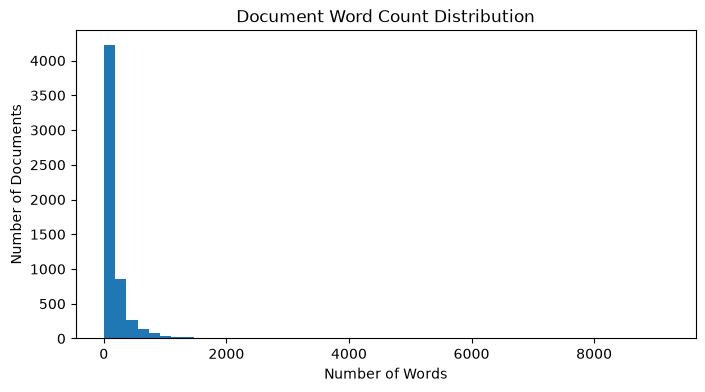

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df["word_count"], bins=50)
plt.title("Document Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.show()

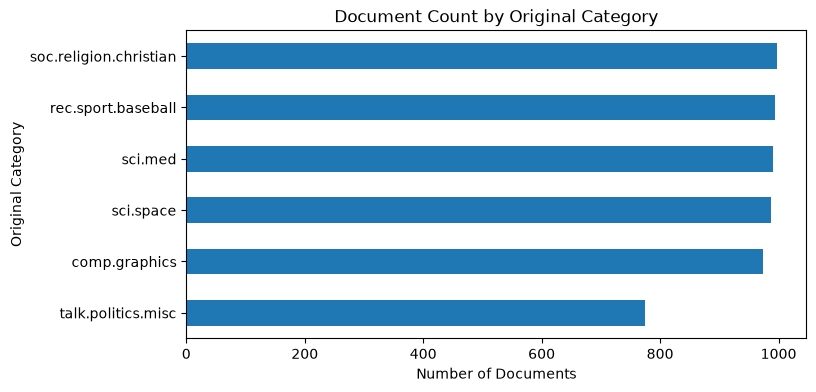

In [7]:
category_counts = df["true_category"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
category_counts.plot(kind="barh")
plt.title("Document Count by Original Category")
plt.xlabel("Number of Documents")
plt.ylabel("Original Category")
plt.show()

In [8]:
for i in range(3):
    print("=" * 80)
    print("Category:", df.loc[i, "true_category"])
    print(df.loc[i, "text"][:1000])
    print()

Category: soc.religion.christian

 >    I realize I'm entering this discussion rather late, but I do
 > have one question. Wasn't it a Reagan appointee, James Watt, a
 > pentacostal christian (I think) who was the secretary of the
 > interior who saw no problem with deforestation since we were
 > "living in the last days" and ours would be the last generation
 > to see the redwoods anyway?

For the Record:

On February 5, 1981, at a House of Representatives
Interior Committee Meeting, Rep. James Weaver (D, Ore), asked Watt
whether "you agree that we should save some of our scenic resources
for our children, not just gobble them up all at once?" Watt's
answer was:

 < Absolutely. That is the delicate balance the Secretary of the
 < Interior must have -- to be steward for the natural resources
 < for this generation as well as future generations. I do not
 < know how many future generations we can count on before the
 < Lord returns.  Whatever it is, we have to manage with a skill
 < to 

## Text inspection 

The documents vary heavily in length.

Before cleaning, the average document length was about 1,300 characters and the average word count was about 210 words. Some documents were empty or very short, while the longest document had more than 9,000 words.

The selected categories cover clearly different themes, including computer graphics, baseball, medicine, space, religion, and politics. This makes the dataset suitable for topic modelling because there should be meaningful hidden themes for the models to discover.

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,\n > I realize I'm entering this discussion...,i realize i m entering this discussion rather ...
1,"Hell, the Orioles' Opening Day game could easi...",hell the orioles opening day game could easily...
2,"\n\nLou Gehrig, IRONMAN \n",lou gehrig ironman
3,I am looking for a copy of the following Siggr...,i am looking for a copy of the following siggr...
4,\n\nThis is a point that seems to have been ov...,this is a point that seems to have been overlo...


In [10]:
df["clean_word_count"] = df["clean_text"].str.split().apply(len)

df = df[df["clean_word_count"] >= 20].copy().reset_index(drop=True)

documents_clean = df["clean_text"].tolist()
true_labels_clean = df["true_label_id"].values
true_categories_clean = df["true_category"].values

print("Documents after filtering:", len(df))

Documents after filtering: 5133


## Text cleaning 

Basic text cleaning was applied to lowercase the text, remove email addresses, URLs, punctuation, numbers, and extra whitespace.

Documents with fewer than 20 cleaned words were removed.

After filtering, 5,133 documents remained for topic modelling.

This cleaning step reduced noise and removed very short documents that would not provide enough useful text for topic discovery.

In [11]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(documents_clean)

tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (5133, 5000)


In [12]:
tfidf_density = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])

print(f"TF-IDF matrix density: {tfidf_density:.4%}")

TF-IDF matrix density: 1.1007%


## TF-IDF representation 

The TF-IDF matrix contained 5,133 documents and 5,000 selected terms or phrases.

The matrix density was only 1.1007%, meaning it was very sparse. This is expected in text data because each document only uses a small subset of the full vocabulary.

TF-IDF was used for NMF because it highlights terms that are important within a document while reducing the influence of extremely common words.

In [13]:
count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_counts = count_vectorizer.fit_transform(documents_clean)

count_feature_names = np.array(count_vectorizer.get_feature_names_out())

print("Count matrix shape:", X_counts.shape)

Count matrix shape: (5133, 5000)


## Count representation 

The count matrix also contained 5,133 documents and 5,000 selected terms or phrases.

Unlike TF-IDF, the count matrix stores raw term frequencies.

This representation was used for LDA because LDA is a probabilistic topic model that is usually trained on word count data rather than TF-IDF values.

In [14]:
def get_top_words(model, feature_names, n_top_words=12):
    topic_rows = []
    
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:n_top_words]
        top_terms = feature_names[top_indices]
        
        topic_rows.append({
            "topic": f"Topic {topic_idx}",
            "top_words": ", ".join(top_terms)
        })
    
    return pd.DataFrame(topic_rows)

In [15]:
def plot_top_words(model, feature_names, topic_idx, n_top_words=12, title_prefix="Topic"):
    topic_weights = model.components_[topic_idx]
    top_indices = topic_weights.argsort()[::-1][:n_top_words]
    
    top_terms = feature_names[top_indices][::-1]
    top_scores = topic_weights[top_indices][::-1]
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_terms, top_scores)
    plt.title(f"{title_prefix} {topic_idx}: Top Words")
    plt.xlabel("Weight")
    plt.ylabel("Term")
    plt.show()

In [16]:
def show_representative_documents(df, topic_distribution, topic_idx, n_docs=3):
    topic_scores = topic_distribution[:, topic_idx]
    top_doc_indices = topic_scores.argsort()[::-1][:n_docs]
    
    for rank, doc_idx in enumerate(top_doc_indices, start=1):
        print("=" * 90)
        print(f"Rank {rank}")
        print("Original category:", df.loc[doc_idx, "true_category"])
        print("Topic score:", round(topic_scores[doc_idx], 4))
        print()
        print(df.loc[doc_idx, "text"][:1200])
        print()

In [17]:
N_TOPICS = 6

nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=500
)

nmf_topic_distribution = nmf_model.fit_transform(X_tfidf)

nmf_topic_distribution.shape

(5133, 6)

In [18]:
nmf_topics_df = get_top_words(
    model=nmf_model,
    feature_names=tfidf_feature_names,
    n_top_words=15
)

nmf_topics_df

,topic,top_words
0,Topic 0,"people, don, just, think, like, know, ve, time..."
1,Topic 1,"surrender soon, intellect shameful, shameful s..."
2,Topic 2,"god, jesus, christ, sin, church, faith, bible,..."
3,Topic 3,"year, game, team, games, baseball, hit, runs, ..."
4,Topic 4,"graphics, thanks, image, files, file, format, ..."
5,Topic 5,"space, shuttle, nasa, launch, orbit, moon, ear..."


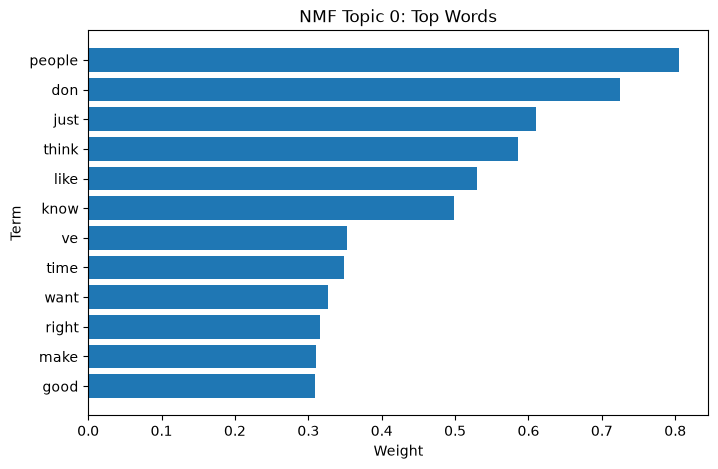

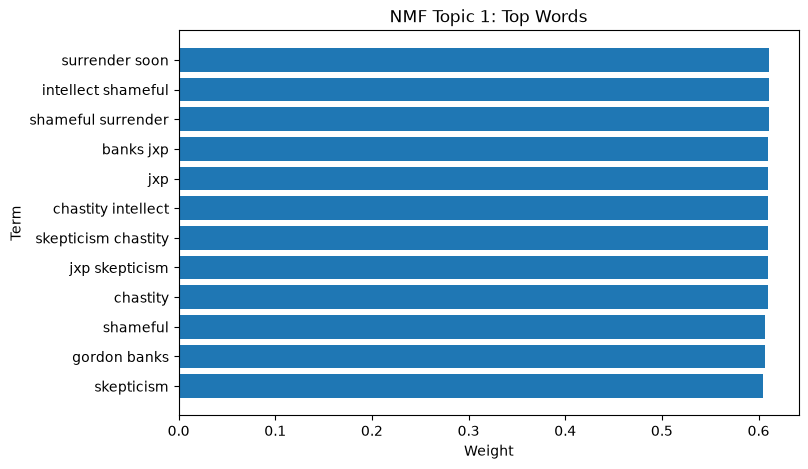

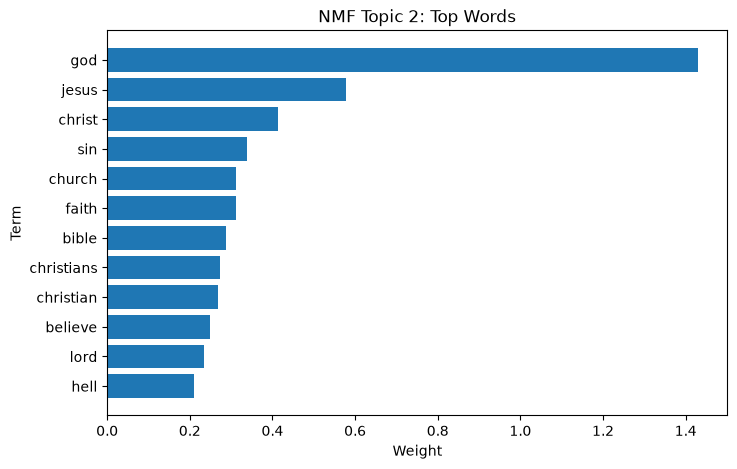

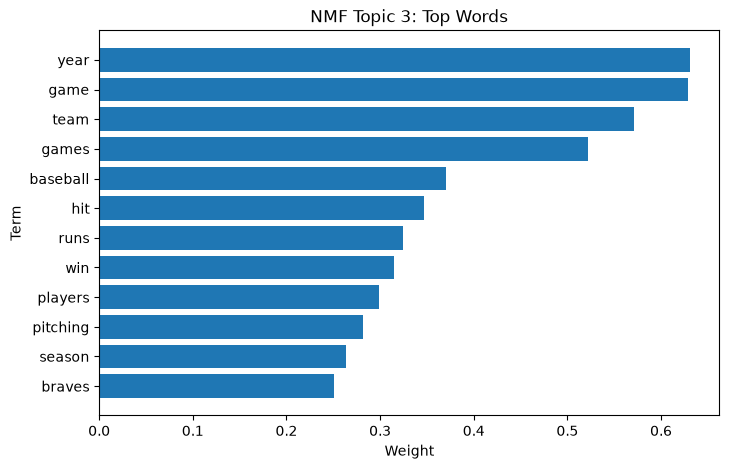

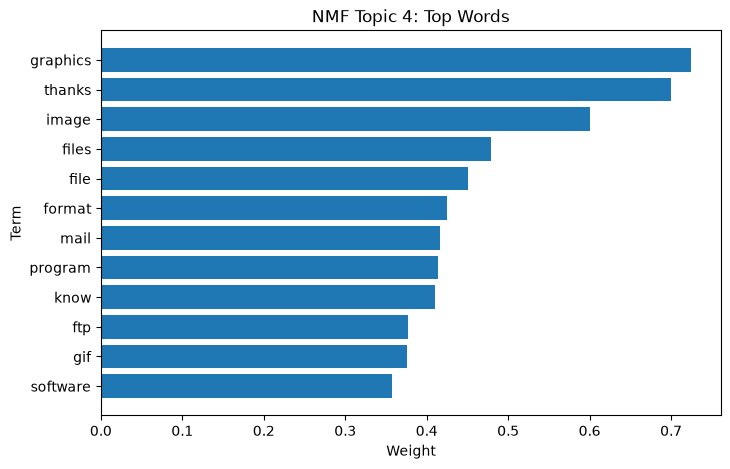

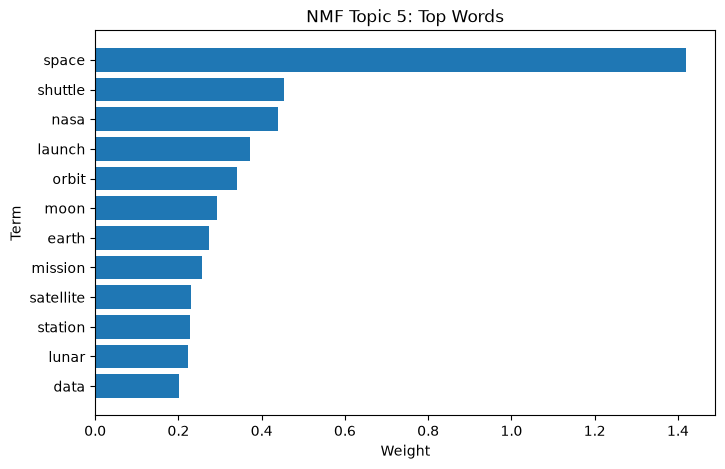

In [19]:
for topic_idx in range(N_TOPICS):
    plot_top_words(
        model=nmf_model,
        feature_names=tfidf_feature_names,
        topic_idx=topic_idx,
        n_top_words=12,
        title_prefix="NMF Topic"
    )

## NMF topics 

The NMF model discovered several meaningful topics.

The clearest topics were:

- Topic 2: Christianity and theology
- Topic 3: Baseball
- Topic 4: Computer graphics
- Topic 5: Space and NASA

Topic 0 was more mixed and contained general discussion words such as people, think, know, time, government, and right. This topic captured broad discussion-style language rather than one clean category.

Topic 1 was unusual. It was dominated by repeated signature-style terms such as “skepticism”, “chastity”, “intellect”, and “surrender”. Although it mostly matched sci.med documents, it seems to capture a repeated signature artifact rather than a meaningful medical topic.

In [20]:
df["nmf_topic_id"] = nmf_topic_distribution.argmax(axis=1)
df["nmf_topic_score"] = nmf_topic_distribution.max(axis=1)

df[["true_category", "nmf_topic_id", "nmf_topic_score", "clean_text"]].head()

,true_category,nmf_topic_id,nmf_topic_score,clean_text
0,soc.religion.christian,0,0.025146,i realize i m entering this discussion rather ...
1,rec.sport.baseball,3,0.139494,hell the orioles opening day game could easily...
2,comp.graphics,4,0.042983,i am looking for a copy of the following siggr...
3,soc.religion.christian,2,0.021505,this is a point that seems to have been overlo...
4,sci.space,5,0.028852,bear in mind that a lot of the vandenberg laun...


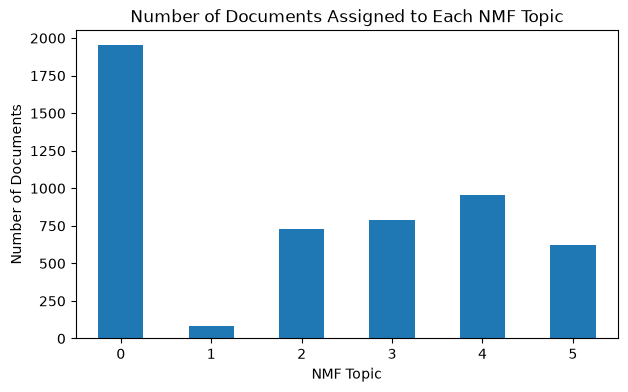

In [21]:
nmf_topic_counts = df["nmf_topic_id"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
nmf_topic_counts.plot(kind="bar")
plt.title("Number of Documents Assigned to Each NMF Topic")
plt.xlabel("NMF Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.show()

In [22]:
nmf_topic_category_table = pd.crosstab(
    df["nmf_topic_id"],
    df["true_category"],
    normalize="index"
)

nmf_topic_category_table

true_category,comp.graphics,rec.sport.baseball,sci.med,sci.space,soc.religion.christian,talk.politics.misc
nmf_topic_id,,,,,,
0,0.047107,0.036866,0.358935,0.129544,0.098310,0.329237
1,0.000000,0.000000,0.963415,0.024390,0.000000,0.012195
2,0.006840,0.002736,0.009576,0.005472,0.956224,0.019152
3,0.013977,0.922490,0.012706,0.022872,0.008895,0.019060
4,0.770355,0.031315,0.101253,0.055324,0.031315,0.010438
5,0.038585,0.001608,0.020900,0.905145,0.006431,0.027331


In [23]:
nmf_topic_category_counts = pd.crosstab(
    df["nmf_topic_id"],
    df["true_category"]
)

nmf_topic_category_counts

true_category,comp.graphics,rec.sport.baseball,sci.med,sci.space,soc.religion.christian,talk.politics.misc
nmf_topic_id,,,,,,
0,92,72,701,253,192,643
1,0,0,79,2,0,1
2,5,2,7,4,699,14
3,11,726,10,18,7,15
4,738,30,97,53,30,10
5,24,1,13,563,4,17


## NMF topic assignment 

Each document was assigned to the NMF topic with the highest topic score.

The NMF topic-category table showed that several discovered topics aligned strongly with the original categories:

- Topic 2 was 95.62% soc.religion.christian
- Topic 3 was 92.25% rec.sport.baseball
- Topic 4 was 77.04% comp.graphics
- Topic 5 was 90.51% sci.space

Topic 0 was the weakest topic because it mixed sci.med, talk.politics.misc, sci.space, and other categories. This suggests that NMF found both clean category-like topics and one broad mixed discussion topic.

In [24]:
for topic_idx in range(N_TOPICS):
    print("\n")
    print("#" * 90)
    print(f"NMF Topic {topic_idx}")
    print("Top words:")
    print(nmf_topics_df.loc[topic_idx, "top_words"])
    print("#" * 90)
    
    show_representative_documents(
        df=df,
        topic_distribution=nmf_topic_distribution,
        topic_idx=topic_idx,
        n_docs=2
    )



##########################################################################################
NMF Topic 0
Top words:
people, don, just, think, like, know, ve, time, want, right, make, good, really, government, did
##########################################################################################
Rank 1
Original category: talk.politics.misc
Topic score: 0.1483

THE WHITE HOUSE

                    Office of the Press Secretary
______________________________________________________________
For Immediate Release                             April 23, 1993     

	     
                  PRESS CONFERENCE BY THE PRESIDENT
	     
	     
                            The East Room 


1:00 P.M. EDT
	     
	     
	     THE PRESIDENT:  Terry, do you have a question?
	     
	     Q	  Mr. President, there's a growing feeling that the 
Western response to bloodshed in Bosnia has been woefully inadequate.  
Holocaust survivor Elie Wiesel asked you yesterday to do something, 
anything to stop the 

## Representative documents 

Representative documents helped confirm the meaning of the NMF topics.

For example, the baseball topic contained documents about teams, games, runs, pitching, and seasons. The graphics topic contained FAQ-style computer graphics documents. The space topic contained NASA, shuttle, launch, orbit, and mission-related documents.

This shows why representative document inspection is important. Top words give a quick summary, but the actual documents reveal whether a topic is genuinely meaningful or partly caused by noise.

In [25]:
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    learning_method="batch",
    max_iter=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lda_topic_distribution = lda_model.fit_transform(X_counts)

lda_topic_distribution.shape

(5133, 6)

In [26]:
lda_topics_df = get_top_words(
    model=lda_model,
    feature_names=count_feature_names,
    n_top_words=15
)

lda_topics_df

,topic,top_words
0,Topic 0,"god, jesus, christ, sin, lord, law, man, fathe..."
1,Topic 1,"people, don, think, just, like, know, does, be..."
2,Topic 2,"image, graphics, jpeg, file, data, available, ..."
3,Topic 3,"medical, health, use, disease, research, drug,..."
4,Topic 4,"president, think, people, mr, don, government,..."
5,Topic 5,"space, year, game, time, like, earth, team, go..."


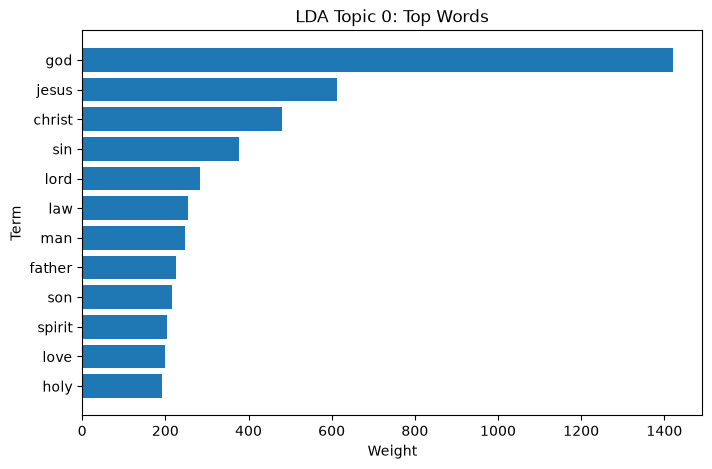

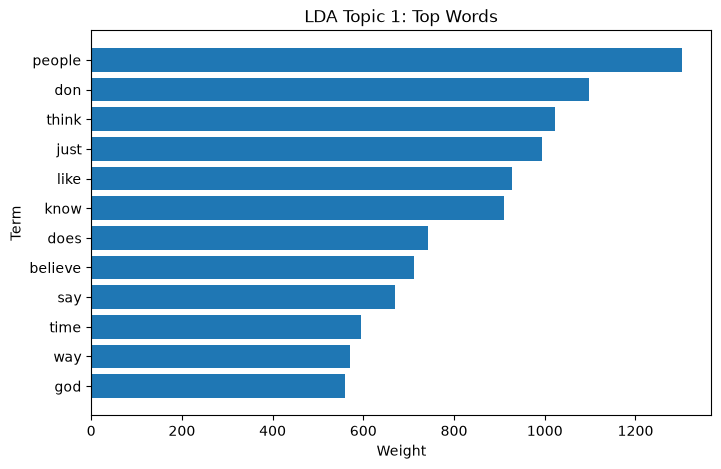

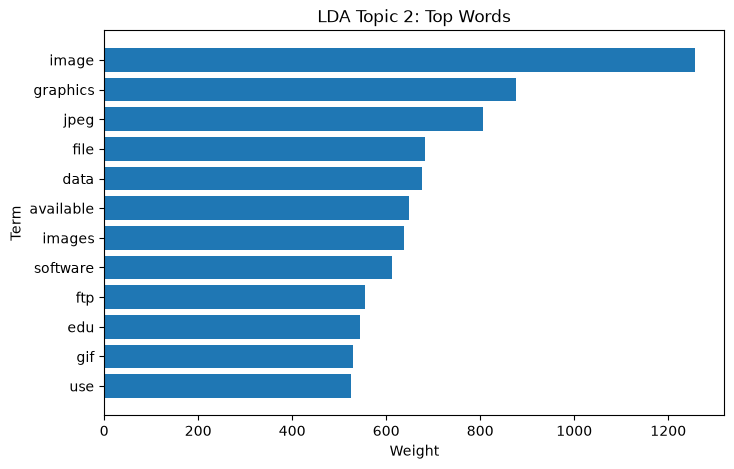

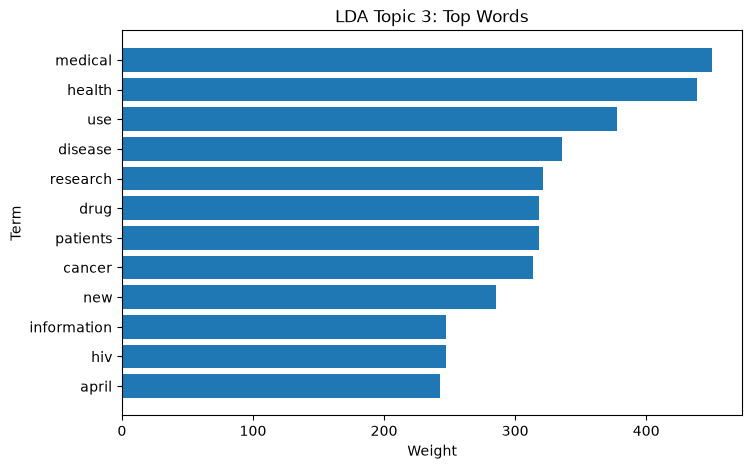

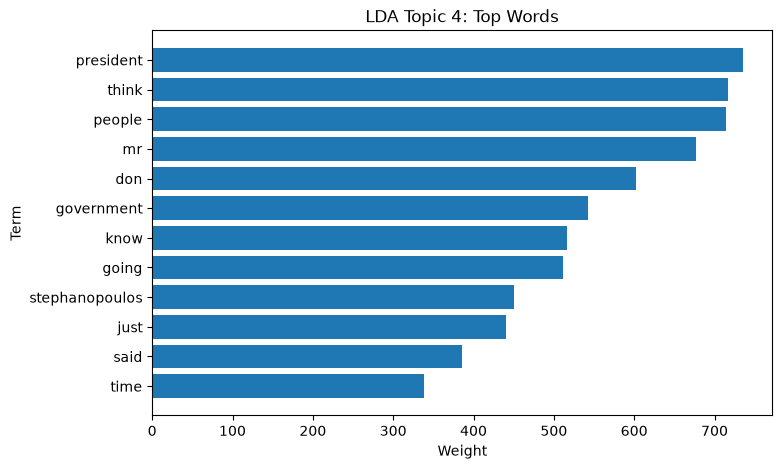

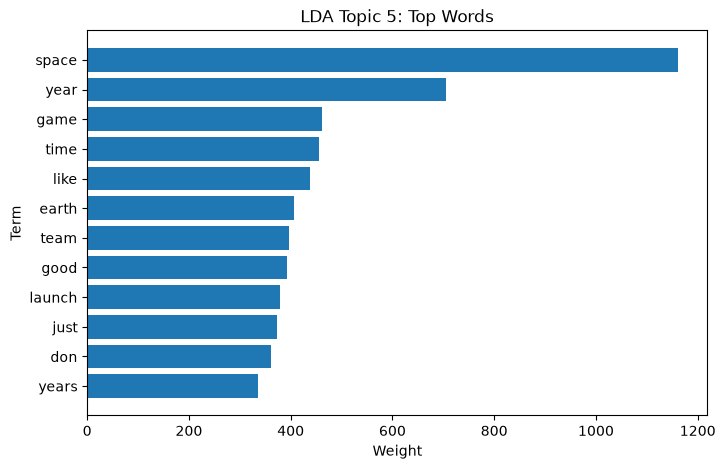

In [27]:
for topic_idx in range(N_TOPICS):
    plot_top_words(
        model=lda_model,
        feature_names=count_feature_names,
        topic_idx=topic_idx,
        n_top_words=12,
        title_prefix="LDA Topic"
    )

## LDA topics 

The LDA model also discovered topic-like word groups, but the topics were generally less clean than NMF.

Some LDA topics were interpretable:

- Topic 0: Christianity
- Topic 2: Computer graphics
- Topic 3: Medicine
- Topic 4: Politics
- Topic 5: Mixed space and baseball

However, several LDA topics mixed multiple categories together. For example, one topic contained broad words such as people, think, know, and believe, while another topic mixed space and baseball terms.

Overall, LDA produced useful themes, but NMF gave cleaner and more category-aligned topics in this notebook.

In [28]:
df["lda_topic_id"] = lda_topic_distribution.argmax(axis=1)
df["lda_topic_score"] = lda_topic_distribution.max(axis=1)

df[["true_category", "lda_topic_id", "lda_topic_score", "clean_text"]].head()

,true_category,lda_topic_id,lda_topic_score,clean_text
0,soc.religion.christian,4,0.430951,i realize i m entering this discussion rather ...
1,rec.sport.baseball,5,0.990108,hell the orioles opening day game could easily...
2,comp.graphics,2,0.961816,i am looking for a copy of the following siggr...
3,soc.religion.christian,1,0.679533,this is a point that seems to have been overlo...
4,sci.space,4,0.307014,bear in mind that a lot of the vandenberg laun...


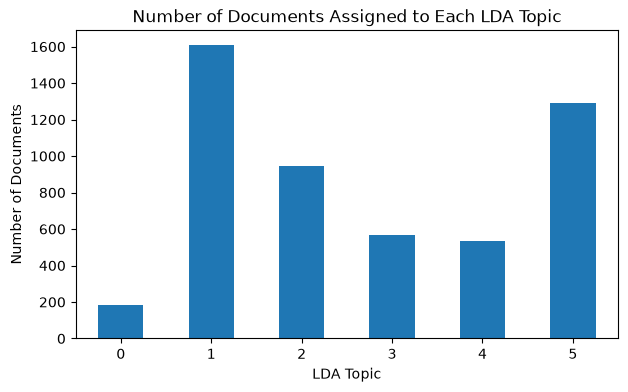

In [29]:
lda_topic_counts = df["lda_topic_id"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
lda_topic_counts.plot(kind="bar")
plt.title("Number of Documents Assigned to Each LDA Topic")
plt.xlabel("LDA Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.show()

In [30]:
lda_topic_category_table = pd.crosstab(
    df["lda_topic_id"],
    df["true_category"],
    normalize="index"
)

lda_topic_category_table

true_category,comp.graphics,rec.sport.baseball,sci.med,sci.space,soc.religion.christian,talk.politics.misc
lda_topic_id,,,,,,
0,0.016129,0.005376,0.026882,0.021505,0.779570,0.150538
1,0.049751,0.042910,0.194030,0.073383,0.462065,0.177861
2,0.804025,0.027542,0.041314,0.103814,0.013771,0.009534
3,0.007030,0.010545,0.887522,0.022847,0.014060,0.057996
4,0.024345,0.024345,0.043071,0.262172,0.035581,0.610487
5,0.008514,0.554180,0.017802,0.402477,0.003096,0.013932


## LDA topic assignment 

Each document was assigned to the LDA topic with the highest topic probability.

The LDA topic-category table showed that some topics were strong, but others were mixed:

- Topic 2 was mostly comp.graphics, with 80.40% purity
- Topic 3 was mostly sci.med, with 88.75% purity
- Topic 0 was mostly soc.religion.christian, with 77.96% purity
- Topic 4 was mostly talk.politics.misc, but also included many sci.space documents
- Topic 5 mixed rec.sport.baseball and sci.space heavily

This suggests that LDA discovered meaningful themes, but it did not separate the selected categories as cleanly as NMF.

In [31]:
nmf_nmi = normalized_mutual_info_score(
    true_categories_clean,
    df["nmf_topic_id"]
)

lda_nmi = normalized_mutual_info_score(
    true_categories_clean,
    df["lda_topic_id"]
)

nmf_ari = adjusted_rand_score(
    true_categories_clean,
    df["nmf_topic_id"]
)

lda_ari = adjusted_rand_score(
    true_categories_clean,
    df["lda_topic_id"]
)

comparison_df = pd.DataFrame([
    {
        "model": "NMF",
        "NMI": nmf_nmi,
        "ARI": nmf_ari
    },
    {
        "model": "LDA",
        "NMI": lda_nmi,
        "ARI": lda_ari
    }
])

comparison_df

,model,NMI,ARI
0,NMF,0.541934,0.433347
1,LDA,0.455088,0.377034


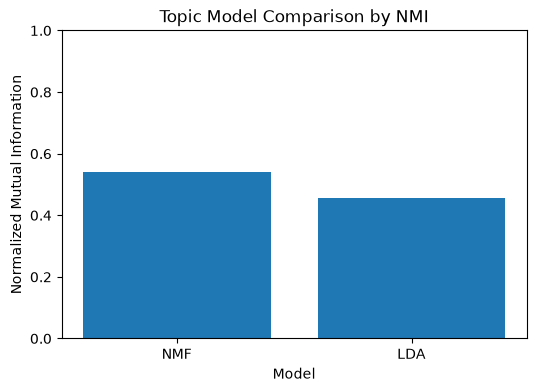

In [32]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"], comparison_df["NMI"])
plt.title("Topic Model Comparison by NMI")
plt.xlabel("Model")
plt.ylabel("Normalized Mutual Information")
plt.ylim(0, 1)
plt.show()

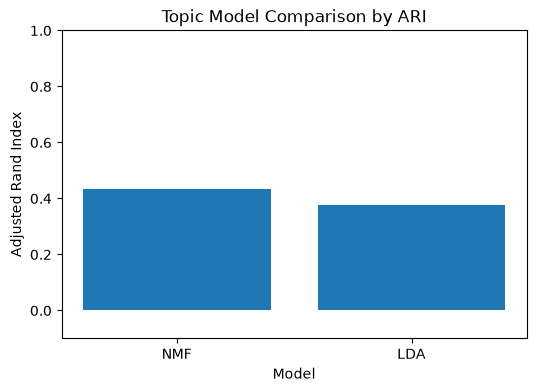

In [33]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"], comparison_df["ARI"])
plt.title("Topic Model Comparison by ARI")
plt.xlabel("Model")
plt.ylabel("Adjusted Rand Index")
plt.ylim(-0.1, 1)
plt.show()

## Topic model comparison 

NMF performed better than LDA based on the post-hoc comparison with the original category labels.

The results were:

| Model | NMI | ARI |
|---|---:|---:|
| NMF | 0.5419 | 0.4333 |
| LDA | 0.4551 | 0.3770 |

NMF achieved higher normalized mutual information and higher adjusted rand index.

This suggests that NMF produced topics that aligned better with the original categories.

These metrics were only used as a sanity check. The topic models were still trained in an unsupervised way without using the labels.

In [34]:
def topic_purity_table(df, topic_col, label_col="true_category"):
    rows = []
    
    for topic_id in sorted(df[topic_col].unique()):
        topic_docs = df[df[topic_col] == topic_id]
        label_counts = topic_docs[label_col].value_counts()
        
        top_label = label_counts.index[0]
        top_count = label_counts.iloc[0]
        total = len(topic_docs)
        
        rows.append({
            "topic_id": topic_id,
            "documents": total,
            "dominant_category": top_label,
            "dominant_category_count": top_count,
            "purity": top_count / total
        })
    
    return pd.DataFrame(rows)


nmf_purity_df = topic_purity_table(df, "nmf_topic_id")
lda_purity_df = topic_purity_table(df, "lda_topic_id")

nmf_purity_df

,topic_id,documents,dominant_category,dominant_category_count,purity
0,0,1953,sci.med,701,0.358935
1,1,82,sci.med,79,0.963415
2,2,731,soc.religion.christian,699,0.956224
3,3,787,rec.sport.baseball,726,0.922490
4,4,958,comp.graphics,738,0.770355
5,5,622,sci.space,563,0.905145


In [35]:
lda_purity_df

,topic_id,documents,dominant_category,dominant_category_count,purity
0,0,186,soc.religion.christian,145,0.779570
1,1,1608,soc.religion.christian,743,0.462065
2,2,944,comp.graphics,759,0.804025
3,3,569,sci.med,505,0.887522
4,4,534,talk.politics.misc,326,0.610487
5,5,1292,rec.sport.baseball,716,0.554180


In [36]:
nmf_purity_df["model"] = "NMF"
lda_purity_df["model"] = "LDA"

purity_df = pd.concat([nmf_purity_df, lda_purity_df], ignore_index=True)

purity_df

,topic_id,documents,dominant_category,dominant_category_count,purity,model
0,0,1953,sci.med,701,0.358935,NMF
1,1,82,sci.med,79,0.963415,NMF
2,2,731,soc.religion.christian,699,0.956224,NMF
3,3,787,rec.sport.baseball,726,0.922490,NMF
4,4,958,comp.graphics,738,0.770355,NMF
5,5,622,sci.space,563,0.905145,NMF
6,0,186,soc.religion.christian,145,0.779570,LDA
7,1,1608,soc.religion.christian,743,0.462065,LDA
8,2,944,comp.graphics,759,0.804025,LDA
9,3,569,sci.med,505,0.887522,LDA


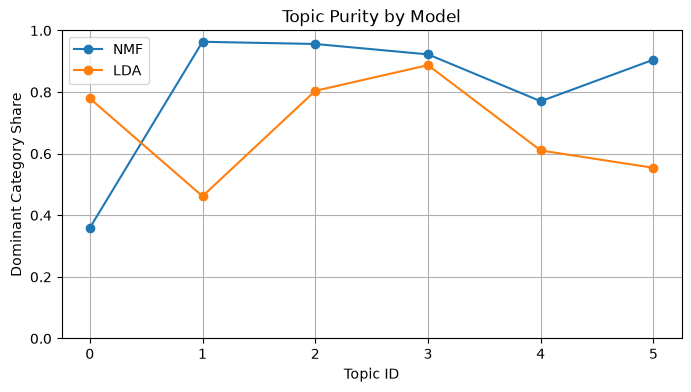

In [37]:
plt.figure(figsize=(8, 4))

for model_name in ["NMF", "LDA"]:
    subset = purity_df[purity_df["model"] == model_name]
    plt.plot(
        subset["topic_id"],
        subset["purity"],
        marker="o",
        label=model_name
    )

plt.title("Topic Purity by Model")
plt.xlabel("Topic ID")
plt.ylabel("Dominant Category Share")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

## Topic purity 

Topic purity measures how concentrated each topic is around one original category.

NMF had a higher mean topic purity of 0.8128, while LDA had a lower mean topic purity of 0.6830.

The strongest NMF topics were highly concentrated:

- NMF Topic 1: 96.34% sci.med, but this appears to be partly a signature artifact
- NMF Topic 2: 95.62% soc.religion.christian
- NMF Topic 3: 92.25% rec.sport.baseball
- NMF Topic 5: 90.51% sci.space

The weakest NMF topic was Topic 0, with only 35.89% purity. This topic mixed several broad discussion categories.

Overall, NMF produced more concentrated and interpretable topics than LDA.

In [38]:
svd = TruncatedSVD(
    n_components=2,
    random_state=RANDOM_STATE
)

X_2d = svd.fit_transform(X_tfidf)

plot_df = pd.DataFrame({
    "x": X_2d[:, 0],
    "y": X_2d[:, 1],
    "nmf_topic_id": df["nmf_topic_id"],
    "lda_topic_id": df["lda_topic_id"],
    "true_category": df["true_category"]
})

plot_df.head()

,x,y,nmf_topic_id,lda_topic_id,true_category
0,0.109715,-0.009774,0,4,soc.religion.christian
1,0.139676,-0.003379,3,5,rec.sport.baseball
2,0.072323,-0.005395,4,2,comp.graphics
3,0.086948,-0.009046,2,1,soc.religion.christian
4,0.056044,0.001341,5,4,sci.space


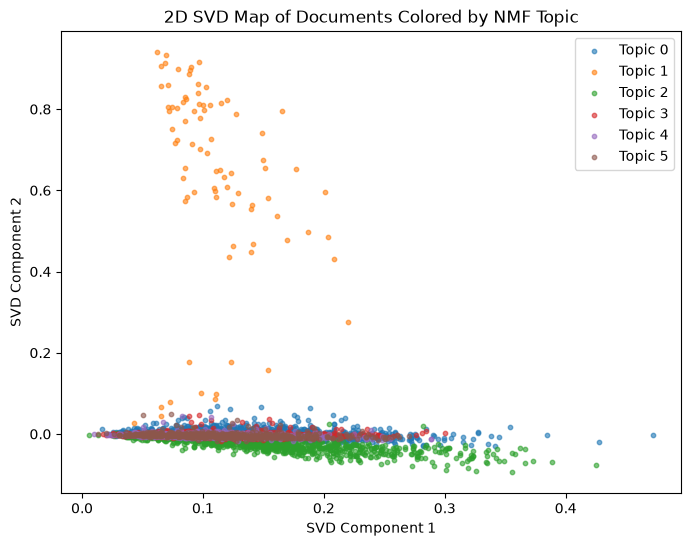

In [39]:
plt.figure(figsize=(8, 6))

for topic_id in sorted(plot_df["nmf_topic_id"].unique()):
    topic_data = plot_df[plot_df["nmf_topic_id"] == topic_id]
    plt.scatter(
        topic_data["x"],
        topic_data["y"],
        s=10,
        alpha=0.6,
        label=f"Topic {topic_id}"
    )

plt.title("2D SVD Map of Documents Colored by NMF Topic")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.show()

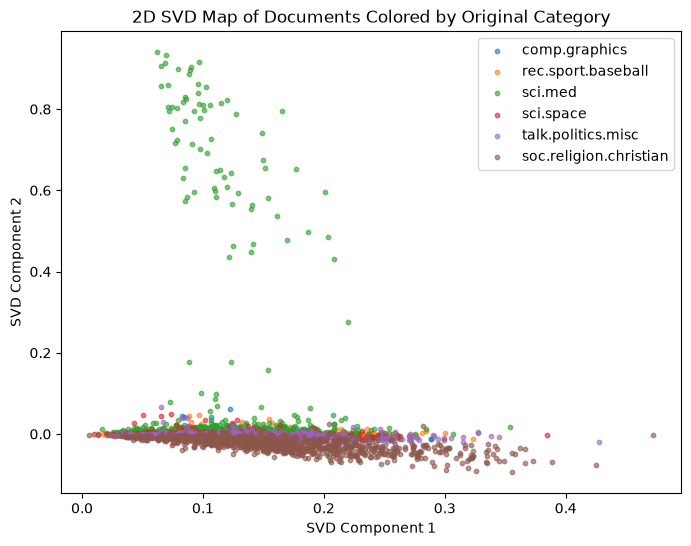

In [40]:
plt.figure(figsize=(8, 6))

for category in selected_categories:
    category_data = plot_df[plot_df["true_category"] == category]
    plt.scatter(
        category_data["x"],
        category_data["y"],
        s=10,
        alpha=0.6,
        label=category
    )

plt.title("2D SVD Map of Documents Colored by Original Category")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend()
plt.show()

## Document map 

The SVD document map gives a rough two-dimensional view of the TF-IDF document space.

Some topics form visible regions, especially the clearer NMF topics such as computer graphics, religion, baseball, and space.

However, there is also overlap between categories. This is expected because text data is high-dimensional, and two SVD components cannot capture all semantic differences between documents.

The map is useful for visual exploration, but it should not be treated as a complete representation of the topic structure.

In [41]:
def search_topic_documents(df, topic_col, topic_id, n_docs=5):
    score_col = topic_col.replace("_id", "_score")
    
    topic_docs = (
        df[df[topic_col] == topic_id]
        .sort_values(score_col, ascending=False)
        .head(n_docs)
    )
    
    for _, row in topic_docs.iterrows():
        print("=" * 90)
        print("Original category:", row["true_category"])
        print("Topic score:", round(row[score_col], 4))
        print()
        print(row["text"][:1200])
        print()

In [42]:
search_topic_documents(
    df=df,
    topic_col="nmf_topic_id",
    topic_id=0,
    n_docs=3
)

Original category: talk.politics.misc
Topic score: 0.1483

THE WHITE HOUSE

                    Office of the Press Secretary
______________________________________________________________
For Immediate Release                             April 23, 1993     

	     
                  PRESS CONFERENCE BY THE PRESIDENT
	     
	     
                            The East Room 


1:00 P.M. EDT
	     
	     
	     THE PRESIDENT:  Terry, do you have a question?
	     
	     Q	  Mr. President, there's a growing feeling that the 
Western response to bloodshed in Bosnia has been woefully inadequate.  
Holocaust survivor Elie Wiesel asked you yesterday to do something, 
anything to stop the fighting.  Is the United States considering 
taking unilateral action such as air strikes against Serb artillery 
sites?
	     
	     THE PRESIDENT:  Well, first let me say, as you know, for 
more than a week now we have been seriously reviewing our options for 
further action.  And I want to say, too, let's l

## Topic document search 

The topic document search function makes the topic model easier to interpret by showing actual documents that strongly belong to a selected topic.

For NMF Topic 0, the retrieved documents showed broad discussion and politics-style content. This matches the top words, which were general terms such as people, think, know, right, government, and time.

This confirms that Topic 0 is less specific than the other NMF topics and acts more like a broad discussion topic.

In [46]:
nmf_topic_names = {
    0: "Topic 0 name",
    1: "Topic 1 name",
    2: "Topic 2 name",
    3: "Topic 3 name",
    4: "Topic 4 name",
    5: "Topic 5 name"
}

df["nmf_topic_name"] = df["nmf_topic_id"].map(nmf_topic_names)

df[["true_category", "nmf_topic_id", "nmf_topic_name", "nmf_topic_score"]].head()

,true_category,nmf_topic_id,nmf_topic_name,nmf_topic_score
0,soc.religion.christian,0,Topic 0 name,0.025146
1,rec.sport.baseball,3,Topic 3 name,0.139494
2,comp.graphics,4,Topic 4 name,0.042983
3,soc.religion.christian,2,Topic 2 name,0.021505
4,sci.space,5,Topic 5 name,0.028852


In [47]:
df["nmf_topic_name"].value_counts()

nmf_topic_name
Topic 0 name    1953
Topic 4 name     958
Topic 3 name     787
Topic 2 name     731
Topic 5 name     622
Topic 1 name      82
Name: count, dtype: int64

## Manual topic naming 

The NMF topics were manually named based on their top words, category alignment, and representative documents.

The final topic names were:

- Topic 0: General discussion / politics and mixed debate
- Topic 1: Medical signature artifact
- Topic 2: Christianity and theology
- Topic 3: Baseball
- Topic 4: Computer graphics
- Topic 5: Space and NASA

Manual naming is subjective, but it makes the topic model easier to communicate.

Topic 1 should be interpreted carefully because it appears to capture repeated signature text rather than a meaningful topic.

In [45]:
summary_df = pd.DataFrame([
    {
        "model": "NMF",
        "documents": len(df),
        "topics": N_TOPICS,
        "NMI": nmf_nmi,
        "ARI": nmf_ari,
        "mean_topic_purity": nmf_purity_df["purity"].mean()
    },
    {
        "model": "LDA",
        "documents": len(df),
        "topics": N_TOPICS,
        "NMI": lda_nmi,
        "ARI": lda_ari,
        "mean_topic_purity": lda_purity_df["purity"].mean()
    }
])

summary_df

,model,documents,topics,NMI,ARI,mean_topic_purity
0,NMF,5133,6,0.541934,0.433347,0.812761
1,LDA,5133,6,0.455088,0.377034,0.682975


## Final summary note

The final comparison showed that NMF produced the stronger topic model overall.

The summary results were:

| Model | Documents | Topics | NMI | ARI | Mean topic purity |
|---|---:|---:|---:|---:|---:|
| NMF | 5,133 | 6 | 0.5419 | 0.4333 | 0.8128 |
| LDA | 5,133 | 6 | 0.4551 | 0.3770 | 0.6830 |

NMF had higher NMI, higher ARI, and higher mean topic purity.

This suggests that NMF discovered topics that were more aligned with the original categories and easier to interpret.